# Hypothesis testing concepts: Two-Sample t-Test

We want to determine whether there is a significant difference between the means of two independent datasets (Sample 1 and Sample 2) using a two-sample t-test. We assume equal variances.

## Import Necessary Libraries

In [1]:
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt

# Python Libraries Two Sample T-Test

## Step 1: Define the two independent datasets

In [2]:
data1 = np.array([23.1, 24.3, 22.8, 23.7, 24.0, 23.5])  # Sample 1
data2 = np.array([21.9, 22.5, 22.0, 21.8, 22.2, 21.7])  # Sample 2

## Step 2: Perform the two-sample t-test (pool t-test assumes equal variances)

In [3]:
t_statistic, p_value = stats.ttest_ind(data1, data2, equal_var=True)

## Calculate confidence interval for the difference of means

In [4]:


# mean difference
mean_diff = np.mean(data1) - np.mean(data2)

# sample sizes
n1, n2 = len(data1), len(data2)

# sample variances
s1_sq, s2_sq = np.var(data1, ddof=1), np.var(data2, ddof=1)#delta degree of freedom is 1 because it is sample

# pooled variance
sp_sq = ((n1 - 1) * s1_sq + (n2 - 1) * s2_sq) / (n1 + n2 - 2)

# standard error using pooled variance
std_err = np.sqrt(sp_sq * (1/n1 + 1/n2))

# degrees of freedom
df = n1 + n2 - 2

# 95% confidence interval
ci = stats.t.interval(0.95, df, loc=mean_diff, scale=std_err)

## Step 3: Display results

In [5]:
print(f"Sample 1 Mean: {np.mean(data1):.2f}")
print(f"Sample 2 Mean: {np.mean(data2):.2f}")
print(f"t-Statistic: {t_statistic:.2f}")
print(f"Degrees of Freedom: {df:.2f}")
print(f"p-Value: {p_value:.4f}")
print(f"Confidence Interval of Mean Difference: [{ci[0]:.2f}, {ci[1]:.2f}]")


Sample 1 Mean: 23.57
Sample 2 Mean: 22.02
t-Statistic: 6.03
Degrees of Freedom: 10.00
p-Value: 0.0001
Confidence Interval of Mean Difference: [0.98, 2.12]


## Step 4: Conclusion

In [6]:
alpha = 0.05  # Significance level
if p_value < alpha:
    print("Reject the null hypothesis. The means of the two samples are significantly different.")
else:
    print("Fail to reject the null hypothesis. The means of the two samples are not significantly different.")

Reject the null hypothesis. The means of the two samples are significantly different.


## Step 5: Visualize the data

In [7]:
np.std(data1, ddof=1)


np.float64(0.5573747990954259)

In [8]:
np.std(data2, ddof=1)

np.float64(0.2926886855802026)

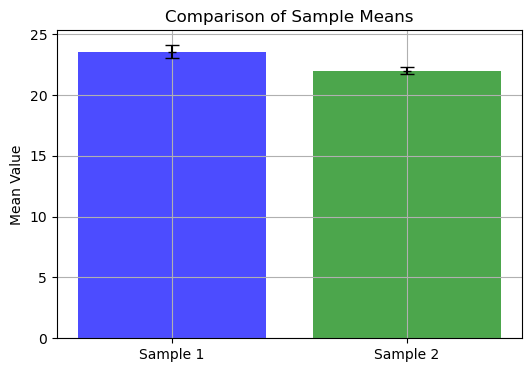

In [9]:
plt.figure(figsize=(6, 4))
plt.bar(['Sample 1', 'Sample 2'], [np.mean(data1), np.mean(data2)], color=['blue', 'green'], alpha=0.7)
plt.errorbar(['Sample 1', 'Sample 2'], [np.mean(data1), np.mean(data2)], yerr=[np.std(data1, ddof=1), np.std(data2, ddof=1)], fmt='k_', capsize=5)
plt.title('Comparison of Sample Means')
plt.ylabel('Mean Value')
plt.grid(True)
plt.show()



---

## Problem Statement

**Perform a two-sample t-test on the following data:**

* **Data 1:** \[18.4, 19.1, 17.9, 18.7, 18.3]
* **Data 2:** \[20.2, 20.5, 20.1, 20.3, 20.4]

Use significance level **α = 0.05** to determine whether the population means differ.

### Tasks

1. State $H_0$ and $H_1$. You will assume **equal variances** (pooled).
2. Compute the **sample means**, **sample variances (ddof = 1)**, and the **mean difference**.
3. Calculate the **t-statistic**, **degrees of freedom**, and the **two-tailed p-value**.
4. Construct the **95% confidence interval** for the mean difference.
5. **Decision & Interpretation:** Conclude (reject / fail to reject $H_0$) and explain the result **in one or two plain-English sentences**.



---




### Solution to Problem Statement

#### 1. Hypotheses Formulation
* **Null Hypothesis ($H_0$):** $\mu_1 = \mu_2$ (or $\mu_1 - \mu_2 = 0$)  
  There is no statistically significant difference between the true population means of Data 1 and Data 2.
* **Alternative Hypothesis ($H_1$):** $\mu_1 \neq \mu_2$ (or $\mu_1 - \mu_2 \neq 0$)  
  There is a statistically significant difference between the true population means of Data 1 and Data 2.
* **Significance Level:** $\alpha = 0.05$ (Two-tailed test, pooled variance assumption).


In [10]:
# Task 2: Compute sample means, sample variances (ddof = 1), and mean difference
data1 = np.array([18.4, 19.1, 17.9, 18.7, 18.3])  # Sample 1
data2 = np.array([20.2, 20.5, 20.1, 20.3, 20.4])  # Sample 2

n1, n2 = len(data1), len(data2)
mean1, mean2 = np.mean(data1), np.mean(data2)
mean_diff = mean1 - mean2

s1_sq = np.var(data1, ddof=1)
s2_sq = np.var(data2, ddof=1)
s1 = np.std(data1, ddof=1)
s2 = np.std(data2, ddof=1)

print("--- Sample Statistics ---")
print(f"Sample 1: Mean = {mean1:.4f}, Variance (ddof=1) = {s1_sq:.4f}, SD = {s1:.4f}, n = {n1}")
print(f"Sample 2: Mean = {mean2:.4f}, Variance (ddof=1) = {s2_sq:.4f}, SD = {s2:.4f}, n = {n2}")
print(f"Point Estimate of Mean Difference (x̄1 - x̄2) = {mean_diff:.4f}")


--- Sample Statistics ---
Sample 1: Mean = 18.4800, Variance (ddof=1) = 0.2020, SD = 0.4494, n = 5
Sample 2: Mean = 20.3000, Variance (ddof=1) = 0.0250, SD = 0.1581, n = 5
Point Estimate of Mean Difference (x̄1 - x̄2) = -1.8200


In [11]:
# Task 3: Calculate degrees of freedom, pooled variance, standard error, t-statistic, and two-tailed p-value
df = n1 + n2 - 2
sp_sq = ((n1 - 1) * s1_sq + (n2 - 1) * s2_sq) / df
std_err = np.sqrt(sp_sq * (1/n1 + 1/n2))

t_statistic = mean_diff / std_err
p_value = 2 * (1 - stats.t.cdf(abs(t_statistic), df))

# SciPy verification
t_scipy, p_scipy = stats.ttest_ind(data1, data2, equal_var=True)

print("--- Inferential Statistics ---")
print(f"Degrees of Freedom (df): {df}")
print(f"Pooled Variance (sp^2): {sp_sq:.4f}")
print(f"Standard Error (SE): {std_err:.4f}")
print(f"t-Statistic: {t_statistic:.4f} (SciPy: {t_scipy:.4f})")
print(f"Two-Tailed p-Value: {p_value:.6f} (SciPy: {p_scipy:.6f})")


--- Inferential Statistics ---
Degrees of Freedom (df): 8
Pooled Variance (sp^2): 0.1135
Standard Error (SE): 0.2131
t-Statistic: -8.5417 (SciPy: -8.5417)
Two-Tailed p-Value: 0.000027 (SciPy: 0.000027)


In [12]:
# Task 4: Construct 95% confidence interval for the mean difference
ci = stats.t.interval(0.95, df, loc=mean_diff, scale=std_err)

print("--- 95% Confidence Interval ---")
print(f"95% Confidence Interval for (μ1 - μ2): [{ci[0]:.4f}, {ci[1]:.4f}]")


--- 95% Confidence Interval ---
95% Confidence Interval for (μ1 - μ2): [-2.3113, -1.3287]


In [13]:
# Task 5: Decision & Plain-English Interpretation
alpha = 0.05
print("=== Decision & Conclusion ===")
if p_value < alpha:
    print(f"Decision: Reject the null hypothesis (H0) at alpha = {alpha} (p = {p_value:.6f} < {alpha}).")
    print("\nInterpretation:")
    print(f"There is a statistically significant difference between the means of Data 1 and Data 2 (t({df}) = {t_statistic:.2f}, p < 0.001). Specifically, the mean of Data 2 ({mean2:.2f}) is significantly higher than that of Data 1 ({mean1:.2f}).")
else:
    print(f"Decision: Fail to reject the null hypothesis (H0) at alpha = {alpha} (p = {p_value:.6f} >= {alpha}).")
    print("\nInterpretation:")
    print("There is no statistically significant difference between the means of the two datasets.")


=== Decision & Conclusion ===
Decision: Reject the null hypothesis (H0) at alpha = 0.05 (p = 0.000027 < 0.05).

Interpretation:
There is a statistically significant difference between the means of Data 1 and Data 2 (t(8) = -8.54, p < 0.001). Specifically, the mean of Data 2 (20.30) is significantly higher than that of Data 1 (18.48).


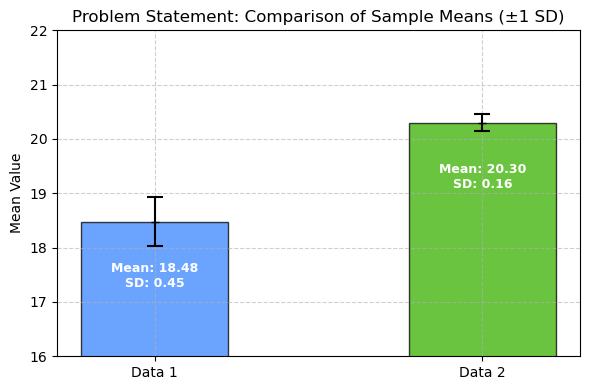

In [14]:
# Visualization: Comparison of Sample Means with Error Bars
plt.figure(figsize=(6, 4))
plt.bar(['Data 1', 'Data 2'], [mean1, mean2], color=['#3a86ff', '#38b000'], alpha=0.75, edgecolor='black', width=0.45)
plt.errorbar(['Data 1', 'Data 2'], [mean1, mean2], yerr=[s1, s2], fmt='k_', capsize=6, elinewidth=1.5, capthick=1.5)
plt.title('Problem Statement: Comparison of Sample Means (±1 SD)')
plt.ylabel('Mean Value')
plt.ylim(16, 22)
plt.grid(True, linestyle='--', alpha=0.6)

# Value annotations
plt.text(0, mean1 - 1.2, f"Mean: {mean1:.2f}\nSD: {s1:.2f}", ha='center', color='white', fontweight='bold', fontsize=9)
plt.text(1, mean2 - 1.2, f"Mean: {mean2:.2f}\nSD: {s2:.2f}", ha='center', color='white', fontweight='bold', fontsize=9)

plt.tight_layout()
plt.show()
